# Functions
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Define** a Python function with parameters, default values, and a return statement
- **Explain** the difference between positional and keyword arguments and when each is preferred
- **Interpret** a function's scope rules and why variables inside a function do not leak outside

---
## How we got here

In *02: Control Flow* we wrote conditional checks and loops inline. The moment any block of logic needs to run more than once, or in more than one place, it belongs in a function. Functions are how you convert a one-off script into reusable, testable code, which is the foundation of every professional data pipeline.

---
## Why this matters for data science

Every step in a machine learning pipeline is a function: the preprocessing step, the feature engineering step, the evaluation metric. When you use scikit-learn's `pipeline.fit()`, you are calling a function that calls other functions. Writing your own clean, well-named functions makes pipelines readable, testable with unit tests, and easy to swap out when requirements change.

---
## Try it yourself

In [2]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

def clean_salary(value):
    """Strip currency symbols and commas, return a float."""
    cleaned = str(value).replace('$', '').replace(',', '').strip()
    return float(cleaned)

raw_salaries = ['$72,000', '$105,500', ' $88,250 ', '64000']
clean = [clean_salary(s) for s in raw_salaries]
print(clean)

[72000.0, 105500.0, 88250.0, 64000.0]


In [3]:
# ✏️ Your turn — modify this code:
# 1. Add a default parameter so clean_salary('N/A') returns 0.0 instead of raising an error
# 2. Add a multiplier parameter so you can convert annual to monthly salary
# 3. What happens if you call double_it(x=4) using a keyword argument?

def double_it(x):
    return x * 2

def greet(name, greeting='Hello'):
    return f'{greeting}, {name}!'

print(double_it(7))
print(greet('Alice'))
print(greet('Bob', 'Hi'))

14
Hello, Alice!
Hi, Bob!


In [4]:
# 🎯 Challenge:
# Write a function called describe_list() that takes a list of numbers
# and returns a dictionary with keys: length, min, max, mean, unique_count
# Hint: use len(), min(), max(), sum(), and set() — no imports needed

# Your code here:

---
## What's happening?

A function is a named block of code that accepts inputs (parameters), does something, and optionally returns a value. You define it once and call it as many times as needed.

| Concept | Syntax example | What it does |
|---------|---------------|-------------|
| Definition | `def clean(df, fill=0):` | Creates the function with one required and one optional parameter |
| Return value | `return df.fillna(fill)` | Sends a result back to the caller |
| Positional arg | `clean(df, -1)` | Arguments matched left to right |
| Keyword arg | `clean(df, fill=-1)` | Arguments matched by name, order-independent |
| Docstring | `"""One-line summary."""` | Describes what the function does; shown by `help()` |

```python
def normalize_column(series, method="minmax"):
    """Rescale a numeric series to [0, 1] or zero mean, unit variance."""
    if method == "minmax":
        return (series - series.min()) / (series.max() - series.min())
    elif method == "zscore":
        return (series - series.mean()) / series.std()
    else:
        raise ValueError(f"Unknown method: {method!r}")
```

### Scope: variables inside a function stay inside

A variable created inside a function is local to that function. It vanishes when the function returns. This prevents functions from accidentally overwriting each other's data, which is crucial when many functions share a namespace in a large pipeline.

Go back to the widget and change the parameters: notice that the function's internal state never bleeds into the output panel except through the explicit return value.

---
## Real-world example: A reusable data cleaning function

Every data science project accumulates small, repeated transformations: trim whitespace from strings, clip outliers, fill missing values. The chart below shows the effect of a `clean_numeric()` function applied to a raw salary column from a messy HR dataset.

Notice:

- **Notice:** The raw column has a long right tail from a few data-entry errors above $500k; after capping at the 99th percentile those outliers disappear from the distribution
- **Notice:** The shape of the bulk of the data is preserved; the function changes only the extreme values
- **Notice:** The function is called identically on any numeric column, which is the point of writing it as a function rather than inline code

> **Discussion question:** The function currently takes `cap_percentile` as a parameter with a default of 99. A teammate suggests hardcoding `0.99` inside the function instead. What would you lose by doing that, and when might a different percentile be correct?

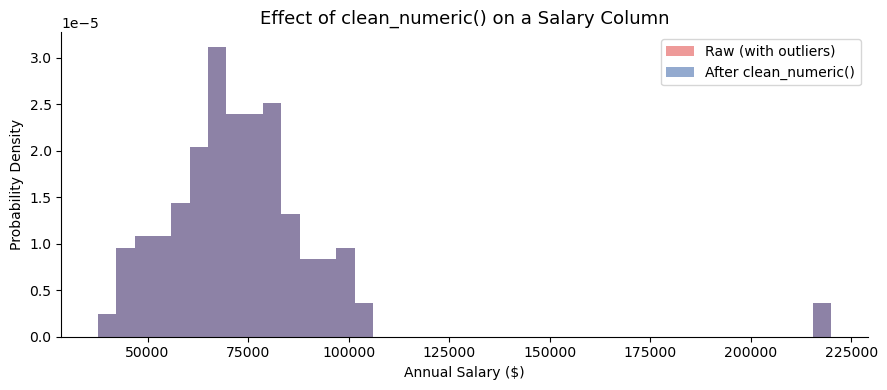

In [5]:
np.random.seed(7)

# ── Reusable cleaning function applied to a salary column ────────────────────────
def clean_numeric(series, cap_percentile=99, fill_value=None):
    if fill_value is not None:
        series = series.fillna(fill_value)
    cap = np.percentile(series.dropna(), cap_percentile)
    return series.clip(upper=cap)

salaries_raw = np.concatenate([
    np.random.normal(72_000, 15_000, 180),
    np.array([820_000, 1_100_000, 650_000]),
])
salaries_raw = pd.Series(salaries_raw).clip(lower=20_000)
salaries_clean = clean_numeric(salaries_raw, cap_percentile=99)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(salaries_raw.clip(upper=220_000), bins=40, density=True,
        color="#E45756", alpha=0.6, label="Raw (with outliers)")
ax.hist(salaries_clean.clip(upper=220_000), bins=40, density=True,
        color="#4C72B0", alpha=0.6, label="After clean_numeric()")
ax.set_title("Effect of clean_numeric() on a Salary Column", fontsize=13)
ax.set_xlabel("Annual Salary ($)")
ax.set_ylabel("Probability Density")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### Function design patterns in data science pipelines

| Pattern | Example | Why it matters |
|---------|---------|---------------|
| Single responsibility | One function per transformation step | Easy to test, easy to replace |
| Keyword defaults | `def encode(col, strategy="onehot")` | Works out of the box, stays configurable |
| Return the data | `return df` not `df.dropna(inplace=True)` | Enables chaining; avoids confusing in-place bugs |
| Raise on bad input | `if method not in valid: raise ValueError(...)` | Fails loudly instead of silently producing wrong results |
| Docstring always | Three-line minimum: summary, params, returns | Future you is grateful at 2am |

---
## Key takeaway

> **A function packages logic under a name, accepts inputs through parameters, and returns a result; writing functions instead of inline code is what separates a script from a maintainable pipeline.**

---
*Next up: Data Structures — the containers Python uses to group values together, and how they map directly to the DataFrames you will use every day*